# Drag analysis:
Plotting drag coefficient, dimensional analysis and time-series analysis for the six taxa.
### Drag Coefficient:
Plot of mean drag coefficient over the last ten timesteps for all taxa
### Dimensional analysis:
Created 26/02/2026
To assess the importance of drag reduction of spiral patterning on stability, dimensional analysis was used. For a given object of homogeneous material properties, if the drag force $F_d$ is assumed to be producing a torque on the centre of mass, the normal contact force, equal to the weight of the object $G'$, has to act a distance $x$ away from the centre line to produce an opposing torque to balance it. Balancing moments about the centre of mass,

$\tau_d = rF_d = xF_N$

$=> x = \frac{rF_d}{G'} = \frac{r\rho_wC_dAU_0^2}{2f_{calcite}Vg(\rho_{calcite}-\rho_w)}$

which is simply

$x = rW$

where W is the dimensionless ratio of drag and weight.If $x>R$, the radius of the base of the object, the normal contact force moves outside of the object and it will topple over. In other words, if $\frac{x}{R}>1$.

Calculates $\frac{x}{R}$ for a range of $U_0$ and $f_{calcite}$ values (as these are highly uncertain) for the spiral and non-spiral echinoderms.

### Time-series analysis:
Analyses the variation in lateral velocity, $`u_y`$, over time to detect von Kármán vortex shedding and how surpression of this may contribute to reduced drag coefficient. Analysis was conducted with free stream velocity of $`0.1`$ m s $`^{-1}`$.

`time_series.csv` and `FFT.csv` files for each taxon were created manually in paraview (see `time_series_analysis.pvsm` in `[taxon]/velocity/v0.1/postProcessing/`).

In [18]:
# Importing libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

from matplotlib import cm
from matplotlib.ticker import LinearLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


### Defining functions:

In [ ]:
def read_drag(taxon, A_frontal):
    # Read the forceCoeffs.dat file and extract Cd values from timestep 30 onwards
    filename = "../" + taxon + "/velocity/v0.1/postProcessing/forces/0/forceCoeffs.dat"
    with open(filename, 'r') as file:
        lines = file.readlines()
        if not lines:
            raise ValueError("The file is empty.")
        data_lines = lines[29:]  # take data from 30s onwards
        Cd_list = []
        for line in data_lines:
            if line.strip() and not line.startswith('#'):
                parts = line.split()
                if len(parts) > 2:
                    Cd_list.append(float(parts[2]))
    mean_Cd = np.mean(Cd_list)*0.00024/A_frontal
    max_Cd = np.max(Cd_list)*0.00024/A_frontal
    min_Cd = np.min(Cd_list)*0.00024/A_frontal
    error_Cd = np.array([mean_Cd - min_Cd, max_Cd - mean_Cd])
    Cd_data = {"mean": mean_Cd, 
               "max": max_Cd, 
               "min": min_Cd,
               "error": error_Cd
               }

    return Cd_data

def calculate_x(A, V, Cd, r, R):
    result = []
    for i in range(len(f_calcite)):
        for j in range(len(U_0)):
            F_d = 0.5*rho_w*Cd*A*U_0[j]**2
            G = f_calcite[i]*V*g*(rho_calcite-rho_w)
            W = F_d/G
            xR = r*W/R
            
            result.append((f_calcite[i], U_0[j], xR))
    df = pd.DataFrame(result, columns=['f_calcite', 'U_0', 'xR'])
    return df


../stromatocystites/velocity/v0.1/postProcessing/forces/0/forceCoeffs.dat
Case stromatocystites: Cd 3.1373087919799496
Cd uncertainty: [0.136201   0.07925331]
../kailidiscus/velocity/v0.1/postProcessing/forces/0/forceCoeffs.dat
Case kailidiscus: Cd 2.656004323450135
Cd uncertainty: [0.0314241  0.03254405]
../helicocystis_straight/velocity/v0.1/postProcessing/forces/0/forceCoeffs.dat
Case helicocystis_straight: Cd 3.389739136065574
Cd uncertainty: [0.05120704 0.04240736]
../helicocystis/velocity/v0.1/postProcessing/forces/0/forceCoeffs.dat
Case helicocystis: Cd 2.9137028744065603
Cd uncertainty: [0.03608808 0.02439939]
../gogia_palmeri/velocity/v0.1/postProcessing/forces/0/forceCoeffs.dat
Case gogia_palmeri: Cd 5.0307044877344875
Cd uncertainty: [0.11816328 0.13816854]
../gogia_spiralis/velocity/v0.1/postProcessing/forces/0/forceCoeffs.dat
Case gogia_spiralis: Cd 4.921996144869215
Cd uncertainty: [0.12862784 0.17480493]
[3.13730879 2.65600432 3.38973914 2.91370287 5.03070449 4.92199614]

/tmp/jmcdermo_10565305/ipykernel_1743934/3965884135.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


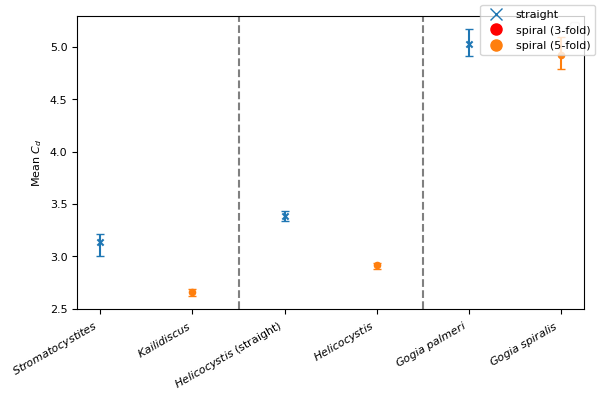

In [ ]:
def read_drag(taxon, A_frontal):
    # Read the forceCoeffs.dat file and extract Cd values from timestep 30 onwards
    filename = "../" + taxon + "/velocity/v0.1/postProcessing/forces/0/forceCoeffs.dat"
    with open(filename, 'r') as file:
        lines = file.readlines()
        if not lines:
            raise ValueError("The file is empty.")
        data_lines = lines[29:]  # take data from 30s onwards
        Cd_list = []
        for line in data_lines:
            if line.strip() and not line.startswith('#'):
                parts = line.split()
                if len(parts) > 2:
                    Cd_list.append(float(parts[2]))
    mean_Cd = np.mean(Cd_list)*0.00024/A_frontal
    max_Cd = np.max(Cd_list)*0.00024/A_frontal
    min_Cd = np.min(Cd_list)*0.00024/A_frontal
    error_Cd = np.array([mean_Cd - min_Cd, max_Cd - mean_Cd])
    Cd_data = {"mean": mean_Cd, 
               "max": max_Cd, 
               "min": min_Cd,
               "error": error_Cd
               }

    return Cd_data

#taxon = np.array(["gogia_palmeri", "gogia_spiralis", "stromatocystites",  "kailidiscus", "helicocystis_straight", "helicocystis", "helicoplacus"])
taxon = np.array(["stromatocystites", "kailidiscus", "helicocystis_straight", "helicocystis", "gogia_palmeri", "gogia_spiralis"])
arr = np.arange(0,len(taxon),1)
max_Cd, mean_Cd, min_Cd = (np.zeros(len(taxon)) for _ in range(3))
errors_Cd = np.zeros((2, len(taxon)))  # 2 rows for lower and upper uncertainty
errors_Cl = np.zeros((2, len(taxon)))

# Frontal areas in m^2 for each taxon
#A_frontal = np.array([0.000792, 0.000284, 0.00114, 0.00106, 0.00024, 0.0000331, 0.000443]) # frontal area for Helicocystis straight is already defined correctly in its controlDict: 0.00024/0.00024 = 1.
A_frontal = {"stromatocystites": 0.00114,
             "kailidiscus": 0.00106,
             "helicocystis_straight": 0.00024,
             "helicocystis": 0.0000331, 
             "gogia_palmeri": 0.000792, 
             "gogia_spiralis": 0.000284, 
             "helicoplacus": 0.000443
             }
# Extracting data and rescaling to correct frontal area
for i in range(len(taxon)):
    file = "../" + taxon[i] + "/velocity/v0.1/postProcessing/forces/0/forceCoeffs.dat"
    print(file)
    Cd_data = extract_coeffs(file)
    #Cl_data = extract_coeffs(file)[1]
    max_Cd[i], mean_Cd[i], min_Cd[i] = Cd_data.max(), Cd_data.mean(), Cd_data.min()
    #rescaling to measured frontal area (original area 0.00024 m^2):
    max_Cd[i], mean_Cd[i], min_Cd[i] = max_Cd[i]*0.00024/list(A_frontal.items())[i][1], mean_Cd[i]*0.00024/list(A_frontal.items())[i][1], min_Cd[i]*0.00024/list(A_frontal.items())[i][1]  
    print(f"Case {taxon[i]}: Cd {mean_Cd[i]}")
    errors_Cd[[0],i] = mean_Cd[i] - min_Cd[i]
    errors_Cd[[1],i] = max_Cd[i] - mean_Cd[i]
    print(f"Cd uncertainty: {errors_Cd[:,i]}")

# Calculating percentage difference:
Cd_diff = np.zeros(len(taxon))
Cd_reldiff = np.zeros(len(taxon))
for i in range(len(mean_Cd)-1):
    Cd_diff[i] = (mean_Cd[i]/mean_Cd[-1]-1)*100
    Cd_reldiff[i+1] = (mean_Cd[i+1]/mean_Cd[i]-1)*100 



print(mean_Cd)
print(errors_Cd)
plt.rcParams.update({'font.size': 8})
# replaced plotting block to alternate marker and color per point
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
#pl_taxa = np.array(["Gogia palmeri", "Gogia spiralis", "Stromatocystites",  "Kailidiscus", "Helicocystis straight", "Helicocystis", "Helicoplacus"])

#labels = [r"$\it{Gogia}$ $\it{palmeri}$", r"$\it{Gogia}$ $\it{spiralis}$", r"$\it{Stromatocystites}$",  r"$\it{Kailidiscus}$", r"$\it{Helicocystis}$ (straight)", r"$\it{Helicocystis}$", r"$\it{Helicoplacus}$"]
labels = [r"$\it{Stromatocystites}$",  r"$\it{Kailidiscus}$", r"$\it{Helicocystis}$ (straight)", r"$\it{Helicocystis}$", r"$\it{Gogia}$ $\it{palmeri}$", r"$\it{Gogia}$ $\it{spiralis}$"]
x = np.arange(len(taxon))

# alternating markers and colours: even -> 'x' blue, odd -> 'o' orange
markers = ['x', 'o', 'x', 'o', 'x','o']
colors = ['C0', 'C1', 'C0', 'C1', 'C0', 'C1']

for i in range(len(taxon)):
    xi = [x[i]]
    yi = [mean_Cd[i]]
    err = errors_Cd[:, i].reshape(2, 1)  # shape (2,1) matches one y value

    ax.scatter(xi, yi, marker=markers[i], color=colors[i], s=20, zorder=3)
    ax.errorbar(xi, yi, yerr=err, fmt='none', ecolor=colors[i], capsize=3, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')

## vertical lines to separate groups ##
n_groups = 6
index = np.arange(n_groups)
ax.axvline(index[1]+0.5, color='gray', linestyle='dashed')
ax.axvline(index[3]+0.5, color='gray', linestyle='dashed')

## legend ##
# build a deduplicated legend (one entry per location)
handles, labels = ax.get_legend_handles_labels()
by_label = {}
for h, l in zip(handles, labels):
    if l not in by_label:
        by_label[l] = h

# custom marker legend entries for 'x' and 'o'
x_handle = Line2D([0], [0], color='C0', marker='x', linestyle='None', markersize=8, label='straight (5-fold)')
o_handle1 = Line2D([0], [0], color='red', marker='o', linestyle='None', markersize=8, label='spiral (3-fold)')
o_handle2 = Line2D([0], [0], color='C1', marker='o', linestyle='None', markersize=8, label='spiral (5-fold)')

# combine location handles + linestyle handles
all_handles = list(by_label.values()) + [x_handle, o_handle1, o_handle2]
all_labels = list(by_label.keys()) + ['straight', 'spiral (3-fold)', 'spiral (5-fold)']

fig.legend(
    all_handles,
    all_labels,
    loc='upper right',
)


ax.set_ylabel(r'Mean $C_d$')
plt.legend()
plt.tight_layout()

In [ ]:
A_frontal = {"stromatocystites": 0.00114,
             "kailidiscus": 0.00106,
             "helicocystis_straight": 0.00024,
             "helicocystis": 0.0000331, 
             "gogia_palmeri": 0.000792, 
             "gogia_spiralis": 0.000284, 
             "helicoplacus": 0.000443
             }
print(list(A_frontal.items())[0][1])

## Dimensional analysis: parameter exploration
Created 26/02/2026
To assess the importance of drag reduction of spiral patterning on stability, dimensional analysis was used. For a given object of homogeneous material properties, if the drag force $F_d$ is assumed to be producing a torque on the centre of mass, the normal contact force, equal to the weight of the object $G'$, has to act a distance $x$ away from the centre line to produce an opposing torque to balance it. Balancing moments about the centre of mass,

$\tau_d = rF_d = xF_N$

$=> x = \frac{rF_d}{G'} = \frac{r\rho_wC_dAU_0^2}{2f_{calcite}Vg(\rho_{calcite}-\rho_w)}$

which is simply

$x = rW$

where W is the dimensionless ratio of drag and weight.If $x>R$, the radius of the base of the object, the normal contact force moves outside of the object and it will topple over. In other words, if $\frac{x}{R}>1$.

This notebook calculates $\frac{x}{R}$ for a range of $U_0$ and $f_{calcite}$ values (as these are highly uncertain) for the spiral and non-spiral echinoderms.



In [61]:
# Defining constants
rho_w = 1025  # Density of water in kg/m^3
rho_calcite = 2710  # Density of calcite in kg/m^3
g = 9.81  # Acceleration due to gravity in m/s^2
f_calcite = np.linspace(0.1,0.6,50)
U_0 = np.linspace(0,0.5,50)

def calculate_x(A, V, Cd, r, R):
    result = []
    for i in range(len(f_calcite)):
        for j in range(len(U_0)):
            F_d = 0.5*rho_w*Cd*A*U_0[j]**2
            G = f_calcite[i]*V*g*(rho_calcite-rho_w)
            W = F_d/G
            xR = r*W/R
            
            result.append((f_calcite[i], U_0[j], xR))
    df = pd.DataFrame(result, columns=['f_calcite', 'U_0', 'xR'])
    return df

In [62]:
def plot_x(df, taxon):
    fig, ax = plt.subplots(figsize=(4, 3), layout='constrained')

    # we want distinct colors below and above W=1; center the normalization there
    vmin = df['xR'].min()
    #vmax = df['W'].max()
    vmax = 2
    norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)

    # use a diverging map that clearly shows negative/positive swing
    cmap = plt.get_cmap('turbo')

    # create the hexbin and keep its mappable
    hb = ax.hexbin(
        df['f_calcite'], df['U_0'], C=df['xR'], gridsize=25,
        cmap=cmap, norm=norm
    )
    xlim = df['f_calcite'].min(), df['f_calcite'].max()
    ylim = df['U_0'].min(), df['U_0'].max()
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(r'f$_{calcite}$')
    ax.set_ylabel(r'U$_0$')
    ax.set_title(taxon)

    # add colorbar alongside axes
    cbar = fig.colorbar(
        hb,
        ax=ax,
        orientation='vertical',
        ticks=[0, 0.24, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2],
        extend='both',
        spacing='uniform',
        label='x/R',
    )
    

#fig.tight_layout()

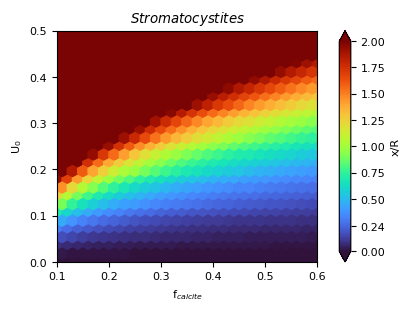

In [63]:
# Stomatocystites:
stromatocystites_df = calculate_x(A = 0.00114, V = 2.66E-5, Cd = 3.13730879, r = 7.27E-3, R = 0.005)
plot_x(stromatocystites_df, r'$\it{Stromatocystites}$')
#plt.savefig('stromatocystites_x.png', dpi=300)

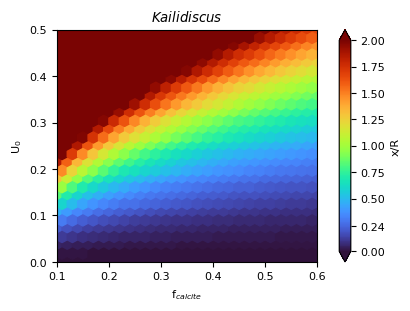

In [64]:
# Kailidiscus:
kailidiscus_df = calculate_x(A = 0.00106, V = 3.01E-5, Cd = 2.65600432, r = 0.0167405, R = 0.012)
plot_x(kailidiscus_df, r'$\it{Kailidiscus}$')
#plt.savefig('kailidiscus_x.png', dpi=300)

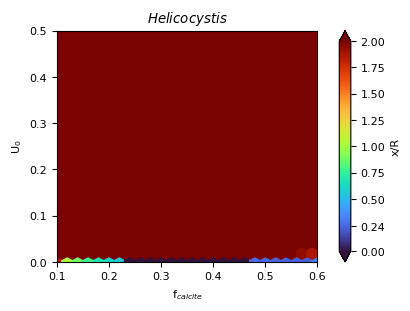

In [65]:
# Helicocystis:
helico_df = calculate_x(A = 3.31E-5, V = 6.2E-8, Cd = 2.91370287, r = 0.00738148, R = 1E-4)
plot_x(helico_df, r'$\it{Helicocystis}$')
#plt.savefig('helico_x.png', dpi=300)

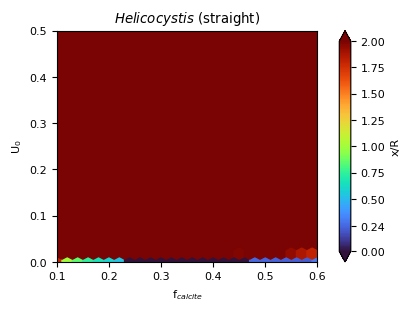

In [66]:
# Helicocsystis straight:
helico_straight_df = calculate_x(A = 0.0000288031, V = 6.5E-8, Cd = 3.38973914, r = 0.00738148, R = 1E-4)
plot_x(helico_straight_df, r'$\it{Helicocystis}$ (straight)')
#plt.savefig('helico_straight_x.png', dpi=300)

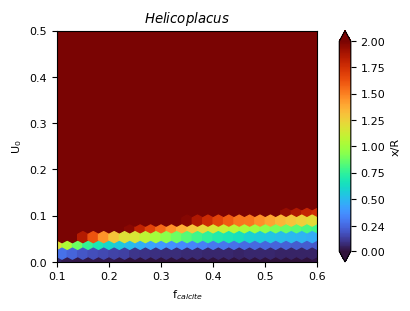

In [67]:
# Helicoplacus:
helicoplacus_df = calculate_x(A = 0.000443, V = 3.92E-6, Cd = 2.72426234, r = 0.02393894, R = 0.0025)
plot_x(helicoplacus_df, r'$\it{Helicoplacus}$')
#plt.savefig('helicoplacus_x.png', dpi=300)

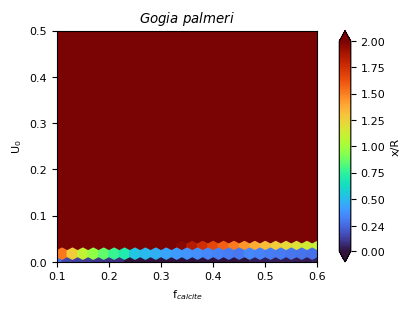

In [68]:
# Gogia palmeri:
gogia_palmeri_df = calculate_x(A = 0.000792, V = 9E-6, Cd = 5.03070449, r = 0.0335649, R = 9E-4)
plot_x(gogia_palmeri_df, r'$\it{Gogia\ palmeri}$')
#plt.savefig('gogia_palmeri_x.png', dpi=300)

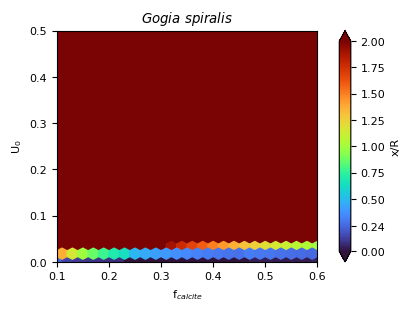

In [69]:
# Gogia spiralis:
gogia_spiralis_df = calculate_x(A = 0.000284, V = 1.1E-6, Cd = 4.92199614, r = 0.02354967, R = 2E-3)
# Scaling to be the same size:
#gogia_spiralis_df['W'] = gogia_spiralis_df['W']*??? A and V would increase, but not at the same rate?? but then drag coefficient would also change maybe.
plot_x(gogia_spiralis_df, r'$\it{Gogia\ spiralis}$')
#plt.savefig('gogia_spiralis_x.png', dpi=300)

TODO: put hexbin plts iside drag plot

Drag data:  {'Taxon': ['$\\it{Stromatocystites}$', '$\\it{Kailidiscus}$', '$\\it{Helicocystis}$ (straight)', '$\\it{Helicocystis}$', '$\\it{Gogia}$ $\\it{palmeri}$', '$\\it{Gogia}$ $\\it{spiralis}$'], 'Mean_Cd': array([3.13730879, 2.65600432, 3.38973914, 2.91370287, 5.03070449,
       4.92199614]), 'Errors': [array([0.136201  , 0.07925331]), array([0.0314241 , 0.03254405]), array([0.05120704, 0.04240736]), array([0.03608808, 0.02439939]), array([0.11816328, 0.13816854]), array([0.12862784, 0.17480493])]}


/tmp/jmcdermo_10565305/ipykernel_1743934/674076834.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(drag_df['Taxon'], fontsize=12)


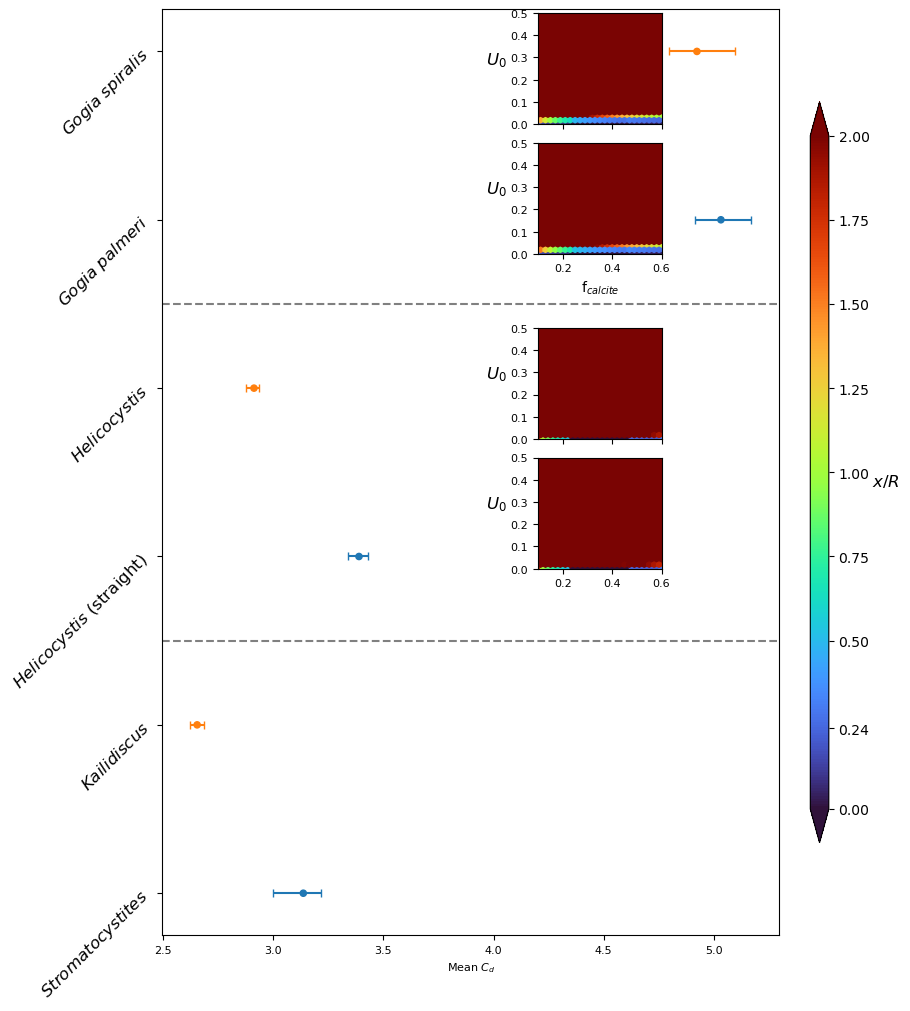

In [121]:
## Combined Figure:
# importing required library
import matplotlib.pyplot as plt
import numpy as np

# creating grid for subplots
fig = plt.figure(layout='constrained')
fig.set_figheight(10)
fig.set_figwidth(9)

ax1 = plt.subplot2grid(shape=(1, 1), loc=(0, 0))
#ax2 = plt.subplot2grid(shape=(6, 4), loc=(0, 2), colspan=1)
#ax3 = plt.subplot2grid(shape=(6, 4), loc=(1, 2), rowspan=1, sharex=ax2)
#ax4 = plt.subplot2grid(shape=(6, 4), loc=(2, 2), rowspan=1)
#ax5 = plt.subplot2grid(shape=(6, 4), loc=(3, 2), rowspan=1)
#ax6 = plt.subplot2grid(shape=(6, 4), loc=(4, 2), rowspan=1)
#ax7 = plt.subplot2grid(shape=(6, 4), loc=(5, 2), rowspan=1)
#ax4 = plt.subplot2grid((3, 3), (2, 0))
#ax5 = plt.subplot2grid((3, 3), (2, 1), colspan=1)

# Sample data in a dictionary
drag_data = {'Taxon': [r"$\it{Stromatocystites}$",  r"$\it{Kailidiscus}$", r"$\it{Helicocystis}$ (straight)", r"$\it{Helicocystis}$", r"$\it{Gogia}$ $\it{palmeri}$", r"$\it{Gogia}$ $\it{spiralis}$"], 
             'Mean_Cd': mean_Cd,
             'Errors': [errors_Cd[:,i] for i in range(len(taxon))]
             }
print("Drag data: ", drag_data)


# Create DataFrame
drag_df = pd.DataFrame(drag_data)

### Draf coefficient plot ###
#pl_taxa = np.array(["Gogia palmeri", "Gogia spiralis", "Stromatocystites",  "Kailidiscus", "Helicocystis straight", "Helicocystis"])
#labels = [r"$\it{Gogia}$ $\it{palmeri}$", r"$\it{Gogia}$ $\it{spiralis}$", r"$\it{Stromatocystites}$",  r"$\it{Kailidiscus}$", r"$\it{Helicocystis}$" "\n(straight)", r"$\it{Helicocystis}$"]
##labels = [r"$\it{Stromatocystites}$",  r"$\it{Kailidiscus}$", r"$\it{Helicocystis}$ (straight)", r"$\it{Helicocystis}$", r"$\it{Gogia}$ $\it{palmeri}$", r"$\it{Gogia}$ $\it{spiralis}$"]
#y = np.arange(len(taxon))
#y = np.flip(y)
#print("Y values: ", y)
#x = np.flip(mean_Cd)
# alternating markers and colours: even -> 'x' blue, odd -> 'o' orange
markers = ['x', 'o', 'x', 'o', 'x','o']
#colors = ['red', 'green', 'red', 'green', 'red', 'green']
# Define alternating colors
colors = ['#1f77b4' if i % 2 == 0 else '#ff7f0e' for i in range(len(x))]
ax1.scatter(drag_df['Mean_Cd'], drag_df['Taxon'],
            s=20, 
            color=colors, 
            marker='o', 
            zorder=3
            )
#ax1.errorbar(drag_df['Mean_Cd'], drag_df['Taxon'], xerr=np.array(drag_df['Errors'].tolist()).T, fmt='none', ecolor=colors, capsize=3, zorder=2)
colors = ['#1f77b4', '#ff7f0e']

for i, row in drag_df.iterrows():
    ax1.errorbar(
        row['Mean_Cd'],
        row['Taxon'],
        xerr=np.array(row['Errors']).reshape(2,1),
        fmt='none',
        ecolor=colors[i % 2],
        capsize=3,
        zorder=2
    )
# A tick label rotation can be set using Axes.tick_params.
ax1.tick_params("y", rotation=45)
ax1.set_yticklabels(drag_df['Taxon'], fontsize=12)

n_groups = 6
index = np.arange(n_groups)
ax1.axhline(index[1]+0.5, color='gray', linestyle='dashed')
ax1.axhline(index[3]+0.5, color='gray', linestyle='dashed')
ax1.set_xlabel(r'Mean $C_d$')


# Gogia spiralis
ax_inset1 = inset_axes(ax1, width="20%", height="12%", 
                      loc="lower left",
                      bbox_to_anchor=(0.6, 0.87, 1, 1),
                      bbox_transform=ax1.transAxes
                      )
ax_inset1.set_ylabel(r'$U_0$', rotation=0, fontsize=12, labelpad=10)
ax_inset1.set_xticklabels([])
# we want distinct colors below and above x/R=1; center the normalization there
vmin = gogia_spiralis_df['xR'].min()
#vmax = df['W'].max()
vmax = 2
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)

# use a diverging map that clearly shows negative/positive swing
cmap = plt.get_cmap('turbo')

# create the hexbin and keep its mappable
hb = ax_inset1.hexbin(
    gogia_spiralis_df['f_calcite'], gogia_spiralis_df['U_0'], C=gogia_spiralis_df['xR'], gridsize=25,
    cmap=cmap, norm=norm
)
xlim = gogia_spiralis_df['f_calcite'].min(), gogia_spiralis_df['f_calcite'].max()
ylim = gogia_spiralis_df['U_0'].min(), gogia_spiralis_df['U_0'].max()
ax_inset1.set_xlim(xlim)
ax_inset1.set_ylim(ylim)


# Gogia palmeri
ax_inset2 = inset_axes(ax1, width="20%", height="12%", 
                      loc="lower left",
                      bbox_to_anchor=(0.6, 0.73, 1, 1),
                      bbox_transform=ax1.transAxes
                      )
ax_inset2.set_ylabel(r'$U_0$', rotation=0, fontsize=12, labelpad=10)
ax_inset2.set_xlabel(r'f$_{calcite}$', fontsize=10)
vmin = gogia_spiralis_df['xR'].min()
vmax = 2
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)
ax_inset2.hexbin(gogia_palmeri_df['f_calcite'], gogia_palmeri_df['U_0'], C=gogia_palmeri_df['xR'], gridsize=25,
    cmap=cmap, norm=norm)
ax_inset2.set_xlim(xlim)
ax_inset2.set_ylim(ylim)


# Helicocystis:
ax_inset3 = inset_axes(ax1, width="20%", height="12%", 
                      loc="lower left",
                      bbox_to_anchor=(0.6, 0.53, 1, 1),
                      bbox_transform=ax1.transAxes
                      )
ax_inset3.set_ylabel(r'$U_0$', rotation=0, fontsize=12, labelpad=10)
vmin = helico_df['xR'].min()
vmax = 2
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)
ax_inset3.hexbin(helico_df['f_calcite'], helico_df['U_0'], C=helico_df['xR'], gridsize=25,
    cmap=cmap, norm=norm)
ax_inset3.set_xticklabels([])
ax_inset3.set_xlim(xlim)
ax_inset3.set_ylim(ylim)

# Helicocystis straight:
ax_inset4 = inset_axes(ax1, width="20%", height="12%", 
                      loc="lower left",
                      bbox_to_anchor=(0.6, 0.39, 1, 1),
                      bbox_transform=ax1.transAxes
                      )
ax_inset4.set_ylabel(r'$U_0$', rotation=0, fontsize=12, labelpad=10)
vmin = helico_df['xR'].min()
vmax = 2
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)
ax_inset4.hexbin(helico_straight_df['f_calcite'], helico_straight_df['U_0'], C=helico_straight_df['xR'], gridsize=25,
    cmap=cmap, norm=norm)
ax_inset4.set_xlim(xlim)
ax_inset4.set_ylim(ylim)

'''
for i in range(len(taxon)):
    yi = [y[i]]
    xi = [x[i]]
    err = np.flip(errors_Cd[:, i].reshape(2, 1))  # shape (2,1) matches one y value

    ax1.scatter(xi, yi, marker=markers[i], color=colors[i], s=20, zorder=3)
    ax1.errorbar(xi, yi, xerr=err, fmt='none', ecolor=colors[i], capsize=3, zorder=2)

print("Labels: ", labels)
ax1.set_yticks(y)
ax1.set_yticklabels(labels, rotation=30, ha='right', fontsize=12)
ax1.set_ylabel("Taxon")

## vertical lines to separate groups ##
n_groups = 6
index = np.arange(n_groups)
ax1.axvline(index[1]+0.5, color='gray', linestyle='dashed')
ax1.axvline(index[3]+0.5, color='gray', linestyle='dashed')

## legend ##
# build a deduplicated legend (one entry per location)
handles, labels = ax1.get_legend_handles_labels()
by_label = {}
for h, l in zip(handles, labels):
    if l not in by_label:
        by_label[l] = h

# custom marker legend entries for 'x' and 'o'
x_handle = Line2D([0], [0], color='C0', marker='x', linestyle='None', markersize=8, label='straight (5-fold)')
o_handle1 = Line2D([0], [0], color='red', marker='o', linestyle='None', markersize=8, label='spiral (3-fold)')
o_handle2 = Line2D([0], [0], color='C1', marker='o', linestyle='None', markersize=8, label='spiral (5-fold)')

# combine location handles + linestyle handles
all_handles = list(by_label.values()) + [x_handle, o_handle1, o_handle2]
all_labels = list(by_label.keys()) + ['straight', 'spiral (3-fold)', 'spiral (5-fold)']

ax1.legend(
    all_handles,
    all_labels,
    loc='upper left',
)


ax1.set_xlabel(r'Mean $C_d$')




##### x/R plots #####
# we want distinct colors below and above x/R=1; center the normalization there
vmin = stromatocystites_df['xR'].min()
#vmax = df['W'].max()
vmax = 2
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)

# use a diverging map that clearly shows negative/positive swing
cmap = plt.get_cmap('turbo')

# create the hexbin and keep its mappable
hb = ax2.hexbin(
    stromatocystites_df['f_calcite'], stromatocystites_df['U_0'], C=stromatocystites_df['xR'], gridsize=25,
    cmap=cmap, norm=norm
)
xlim = stromatocystites_df['f_calcite'].min(), stromatocystites_df['f_calcite'].max()
ylim = stromatocystites_df['U_0'].min(), stromatocystites_df['U_0'].max()
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
#ax2.set_xlabel(r'f$_{calcite}$')
ax2.set_ylabel(r'U$_0$')
#ax2.set_title("Stomatocystites")

ax3.hexbin(
    kailidiscus_df['f_calcite'], kailidiscus_df['U_0'], C=kailidiscus_df['xR'], gridsize=25,
    cmap=cmap, norm=norm
)
ax3.set_xlim(xlim)
ax3.set_ylim(ylim)
ax3.set_ylabel(r'U$_0$')
#ax3.set_title("Kailidiscus")
'''
# create colorbar axis outside figure
#cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.8])

# create standalone mappable
#sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
#sm.set_array([])
'''
cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
    orientation='vertical',
    ticks=[0, 0.24, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2],
    extend='both'
)
'''
cbar = fig.colorbar(hb, ax=[ax1],
                    location='right', shrink=0.8, extend='both', aspect=40)
cbar.set_label(r'$x/R$', rotation=0, labelpad=12, fontsize=12)
cbar.set_ticks([0, 0.24, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2])
cbar.ax.tick_params(labelsize=10)

#cbar.set_label('x/R', rotation=0, labelpad=12, fontsize=12)



#plt.tight_layout()

# automatically adjust padding horizontally 
# as well as vertically.
#plt.tight_layout()

# display plot
#fig.set_constrained_layout(False)
plt.savefig('drag_combined_figure.png', dpi=300, bbox_inches="tight")
plt.show()
